## 0. Setup

### 0.1 Import packages

In [1]:
import seaborn as sns
import numpy as np
import xarray as xr
from functools import wraps
from scipy.interpolate import interp1d
from skimage.measure import find_contours
from haversine import haversine, Unit
from skimage.morphology import convex_hull_image
from typing import List, Tuple
import functools
import time

def log_execution_time(toggle_attr='use_decorators'):
    """Decorator to log execution time, which can be toggled on/off using a class attribute."""
    def decorator(func):
        @functools.wraps(func)
        def wrapper(self, *args, **kwargs):
            if getattr(self, toggle_attr, True):  # Check if decorators are enabled
                start_time = time.time()
                result = func(self, *args, **kwargs)
                end_time = time.time()
                print(f"{func.__name__} executed in {end_time - start_time:.4f} seconds")
                return result
            else:
                return func(self, *args, **kwargs)  # Run function normally if disabled
        return wrapper
    return decorator


class ShapeMeasures:
    def __init__(self, lat_resolution: float = 110.574, lon_resolution: float = 111.320, use_decorators: bool = True):
        """
        A class to compute shape-based metrics for geospatial objects.

        Parameters:
            lat_resolution (float): Resolution of latitude in km per degree.
            lon_resolution (float): Resolution of longitude in km per degree at the equator.
            use_decorators (bool): Toggle for using decorators like execution time logging.
        """
        self.lat_resolution = lat_resolution
        self.lon_resolution = lon_resolution
        self.use_decorators = use_decorators  # Control decorator execution

    @log_execution_time()
    def calculate_area(self, lats: List[float], lons: List[float]) -> float:
        """Computes area in square kilometers."""
        y, x = np.array(lats), np.array(lons)
        dlon = np.cos(np.radians(y)) * self.lon_resolution
        dlat = self.lat_resolution * np.ones(len(dlon))
        return np.sum(dlon * dlat)

    # @log_execution_time()
    # def calculate_spatial_extents(self, one_obj: xr.Dataset) -> dict:
    #     """Computes spatial extents and summary statistics."""
    #     spatial_extents = []
    #     coords_full = []

    #     for i in range(len(one_obj.labels.time)):
    #         stacked = one_obj.labels[i, :, :].stack(zipcoords=['lat', 'lon'])
    #         intermed = stacked.dropna(dim='zipcoords').zipcoords.values

    #         if len(intermed) == 0:
    #             coords_full.append([])
    #             spatial_extents.append(0.0)
    #             continue

    #         lats, lons = zip(*intermed)
    #         coords = list(zip(lats, lons))
    #         coords_full.append(coords)
    #         spatial_extents.append(self.calculate_area(lats, lons))

    #     return {
    #         'coords_full': coords_full,
    #         'spatial_extents': spatial_extents,
    #         'max_spatial_extent': max(spatial_extents, default=0.0),
    #         'max_spatial_extent_time': np.argmax(spatial_extents) if spatial_extents else -1,
    #         'mean_spatial_extent': np.mean(spatial_extents) if spatial_extents else 0.0,
    #         'cumulative_spatial_extent': np.sum(spatial_extents) if spatial_extents else 0.0,
    #     }
    @log_execution_time()
    def calculate_spatial_extents(self, one_obj: xr.Dataset) -> dict:
        """Computes spatial extents and summary statistics."""
        spatial_extents = []
        coords_full = []

        for i in range(len(one_obj.time)):
            stacked = one_obj[i, :, :].stack(zipcoords=['lat', 'lon'])
            intermed = stacked.dropna(dim='zipcoords').zipcoords.values

            if len(intermed) == 0:
                coords_full.append([])
                spatial_extents.append(0.0)
                continue

            lats, lons = zip(*intermed)
            coords = list(zip(lats, lons))
            coords_full.append(coords)
            spatial_extents.append(self.calculate_area(lats, lons))

        return {
            'coords_full': coords_full,
            'spatial_extents': spatial_extents,
            'max_spatial_extent': max(spatial_extents, default=0.0),
            'max_spatial_extent_time': np.argmax(spatial_extents) if spatial_extents else -1,
            'mean_spatial_extent': np.mean(spatial_extents) if spatial_extents else 0.0,
            'cumulative_spatial_extent': np.sum(spatial_extents) if spatial_extents else 0.0,
        }
    @log_execution_time()
    def calculate_perimeter(self, one_obj: xr.Dataset) -> List[float]:
        """Computes the perimeter of objects using contour detection."""
        # Convert longitude from [0, 360] to [-180, 180]
        long_range = interp1d([0, 360], [-180, 180])

        # Replace NaN values with 0 and extract the data
        binary_mask = one_obj.fillna(0).data

        # Precompute latitude and longitude values
        lat_values = one_obj.lat.values
        lon_values = one_obj.lon.values

        # Initialize the list to store perimeters
        perimeters = []

        # Iterate over each time step
        for i in range(len(one_obj.time)):
            # Find contours in the binary mask for the current time step
            contours = find_contours(binary_mask[i], level=0.5)

            # Initialize distances for the current time step
            distances = []

            # Iterate over each contour
            for contour in contours:
                # Extract latitudes and longitudes from the contour
                lats = lat_values[contour[:, 0].astype(int)]
                lons = lon_values[contour[:, 1].astype(int)]

                # Convert longitudes to the range [-180, 180]
                coords = list(zip(lats, long_range(lons)))

                # Calculate distances between consecutive points in the contour
                for ind in range(len(coords) - 1):
                    distances.append(haversine(coords[ind], coords[ind + 1], Unit.KILOMETERS))

                # Close the contour loop by connecting the last point to the first
                distances.append(haversine(coords[-1], coords[0], Unit.KILOMETERS))

            # Sum the distances to get the perimeter for the current time step
            perimeters.append(np.sum(distances))

        return perimeters

    @log_execution_time()
    def calc_complement_to_deformation(self, coords_full: List[List[Tuple[float, float]]], spatial_extents: List[float]) -> np.ndarray:
        """Computes complement to deformation ratio for consecutive timesteps."""
        shared_area_ratios = []
        for i in range(len(coords_full) - 1):
            shared_coords = set(coords_full[i]) & set(coords_full[i + 1])
            if shared_coords:
                y, x = zip(*shared_coords)
                shared_area = np.sum(np.cos(np.radians(y)) * self.lon_resolution * self.lat_resolution)
                shared_area_ratios.append(shared_area / (spatial_extents[i] + spatial_extents[i + 1]))
            else:
                shared_area_ratios.append(0.0)
        return np.array(shared_area_ratios)

    @log_execution_time()
    def calc_deformation(self, shared_area_ratios: List[float]) -> np.ndarray:
        """Computes deformation as 1 - shared area ratio."""
        return 1 - np.array(shared_area_ratios)

    @log_execution_time()
    def calc_ratio_convexhullarea_vs_area(self, one_obj: xr.Dataset) -> List[float]:
        """Computes the ratio of object area to convex hull area."""
        # Initialize the list to store the ratios
        ratios = []
        convex_hull_areas = []
        # Create a binary mask where values > 0 are set to 1 and NaNs are set to 0
        binary_mask = one_obj.where(one_obj > 0, 0).fillna(0)

        # Iterate over each time step
        for i in range(len(one_obj.time)):
            # Extract the object labels for the current time step
            one_obj_one_timestep = one_obj[i, :, :]

            # Stack the latitude and longitude dimensions into a single dimension for easier processing
            obj_onetimestep_stacked = one_obj_one_timestep.stack(zipcoords=['lat', 'lon'])

            # Drop NaN values and extract the coordinates of the object
            intermed = obj_onetimestep_stacked.dropna(dim='zipcoords').zipcoords.values

            # Unpack the latitude and longitude values from the coordinates
            lats, lons = zip(*intermed)

            # Calculate the area of the object using the helper function
            object_area = self.calculate_area(lats, lons)

            # Calculate the convex hull of the binary mask for the current time step
            convex_hull = convex_hull_image(binary_mask[i, :, :])

            # Extract the coordinates of the convex hull
            convex_hull_coords = np.column_stack(np.where(convex_hull))

            # Convert pixel coordinates to latitude and longitude
            lats = one_obj.lat.values[convex_hull_coords[:, 0]]
            lons = one_obj.lon.values[convex_hull_coords[:, 1]]

            # Calculate the area of the convex hull using the helper function
            convex_hull_area = self.calculate_area(lats, lons)
            convex_hull_areas.append(convex_hull_area)
            # Handle edge case: convex hull area is zero
            if convex_hull_area == 0:
                ratios.append(0.0)  # Append 0 if convex hull area is zero
                continue

            # Calculate the ratio of object area to convex hull area
            ratio = object_area / convex_hull_area

            # Append the ratio to the list
            ratios.append(ratio)

        return convex_hull_areas, ratios

    @log_execution_time()
    def calc_circularity(self, area, perimeter):
        """
        Calculate circularity given area and perimeter.

        Parameters:
        area (float or list of floats): The area of the object(s).
        perimeter (float or list of floats): The perimeter of the object(s).

        Returns:
        float or list of floats: Circularity value(s).
        """
        if isinstance(area, list) and isinstance(perimeter, list):
            return [
                4 * np.pi * a / (p ** 2) if p != 0 else np.nan
                for a, p in zip(area, perimeter)
            ]
        elif isinstance(area, (int, float)) and isinstance(perimeter, (int, float)):
            return 4 * np.pi * area / (perimeter ** 2) if perimeter != 0 else np.nan
        else:
            raise ValueError("Both area and perimeter should be numbers or lists of numbers of the same length.")

In [2]:
import xarray as xr
from scipy import ndimage
from scipy.interpolate import interp1d
from skimage import img_as_float
from skimage.morphology import convex_hull_image
from skimage.measure import label as label_np, regionprops, find_contours
from haversine import haversine, Unit
from typing import Dict, Optional, List, Tuple
import numpy as np

def _get_labels(binary_images: np.ndarray) -> np.ndarray:
    """
    Labels connected regions in binary images.

    Parameters
    ----------
    binary_images : np.ndarray
        A 2D or 3D NumPy array representing binary images. Pixels with a value of 1 are considered
        part of a region, while pixels with a value of 0 are considered background.

    Returns
    -------
    np.ndarray
        A labeled array where each connected region is assigned a unique integer label.
        Background pixels are labeled as 0.

    Notes
    -----
    This function replaces NaN values with 0 and ensures the input array contains only finite values
    before applying the labeling algorithm.
    """
    # Replace NaN values with 0 (background)
    binary_images = np.nan_to_num(binary_images, nan=0)
    
    # Ensure the array contains only valid numeric values
    binary_images = np.where(np.isfinite(binary_images), binary_images, 0)
    
    return label_np(binary_images, background=0)

def _get_centroids(sub_labels: xr.DataArray) -> List[Tuple[float, float]]:
    """
    Calculates the centroids of labeled regions.

    Parameters
    ----------
    sub_labels : xr.DataArray
        A labeled xarray DataArray where each connected region is assigned a unique integer label.
        The DataArray must have 'lat' and 'lon' coordinates representing latitude and longitude.

    Returns
    -------
    List[Tuple[float, float]]
        A list of tuples, where each tuple contains the centroid coordinates (latitude, longitude)
        of a labeled region.

    Notes
    -----
    This function uses `skimage.measure.regionprops` to compute the centroids of labeled regions.
    NaN values in the input array are replaced with 0 before processing.
    """
    # Replace NaN values with 0 (background)
    labeled_array = sub_labels.fillna(0).astype(int).values

    # Compute centroids using regionprops
    props = regionprops(labeled_array)
    centroids = [
        (float(sub_labels.lat[round(p.centroid[0])].values),
         float(sub_labels.lon[round(p.centroid[1])].values))
        for p in props
    ]
    return centroids

def centroids_per_timestep(one_obj: xr.DataArray, timestep: int) -> List[Tuple[float, float]]:
    """
    Calculates centroids for each timestep, handling edge cases only if longitude spans 0 to 360.

    Parameters
    ----------
    one_obj : xr.DataArray
        An xarray DataArray containing labeled regions for each timestep. The DataArray must have
        dimensions ('time', 'lat', 'lon') and coordinates for latitude and longitude.
    timestep : int
        The timestep to process. This corresponds to the index along the 'time' dimension.

    Returns
    -------
    List[Tuple[float, float]]
        A list of tuples, where each tuple contains the centroid coordinates (latitude, longitude)
        of a labeled region for the specified timestep.

    Notes
    -----
    This function handles edge cases where regions wrap around the longitudinal boundary (e.g., from
    0 to 360 degrees). If the longitude range spans 0 to 360, regions touching the left and right
    edges are merged before computing centroids.
    """
    # Step 1: Extract the timestep of interest
    timestep_of_interest = one_obj.isel(time=timestep)
    
    # Step 2: Label the regions in the timestep
    sub_labels = _get_labels(timestep_of_interest.values)
    sub_labels = xr.DataArray(sub_labels, dims=timestep_of_interest.dims, coords=timestep_of_interest.coords)
    sub_labels = sub_labels.where(timestep_of_interest > 0, drop=False, other=np.nan)

    # Step 3: Check if longitude spans 0 to 360
    handle_edge_cases = (one_obj.lon[0].item() == 0 and 
                         one_obj.lon[-1].item() == 360)

    # Step 4: Identify edge labels (regions that touch the left or right edge)
    if handle_edge_cases:
        edge_right_sub_labels = np.unique(sub_labels[:, -1:].values[~np.isnan(sub_labels[:, -1:].values)])
        edge_left_sub_labels = np.unique(sub_labels[:, :1].values[~np.isnan(sub_labels[:, :1].values)])
        edge_labels = np.unique(np.concatenate((edge_right_sub_labels, edge_left_sub_labels)))
    else:
        edge_labels = np.array([])  # No edge labels to handle

    # Step 5: Identify non-edge labels
    nonedgecases = np.setdiff1d(np.unique(sub_labels), edge_labels)
    nonedgecases = nonedgecases[~np.isnan(nonedgecases)]

    # Step 6: Compute centroids for non-edge regions
    centroid_list = []
    for i in nonedgecases:
        sub_labels_nonedgecases = sub_labels.where(sub_labels == i, drop=False, other=np.nan)
        centroid_list.append(_get_centroids(sub_labels_nonedgecases))

    # Step 7: Handle edge regions (merge regions that wrap around the longitudinal boundary)
    if handle_edge_cases:
        for i in edge_left_sub_labels:
            sub_labels_left = sub_labels.where(sub_labels == i, drop=True)
            lon_edge = sub_labels_left[:, -1:].lon.item()
            sub_labels_left.coords['lon'] = (sub_labels_left.coords['lon'] + 360)  # Shift left edge to the right

            for j in edge_right_sub_labels:
                sub_labels_right = sub_labels.where(sub_labels == j, drop=False, other=np.nan)
                east = sub_labels_right.where(sub_labels_right.lon > lon_edge, drop=True)
                append_east = xr.concat([east.where(east.lon >= lon_edge, drop=True), sub_labels_left], dim="lon")
                append_east_binarized = xr.where(append_east > 0, 1, np.nan)
                sub_labels_new = _get_labels(append_east_binarized.values)
                sub_labels_new = xr.DataArray(sub_labels_new, dims=append_east_binarized.dims, coords=append_east_binarized.coords)

                # Check if the merged region is valid (contains only one or two labels)
                if len(np.unique(sub_labels_new)) <= 2:
                    sub_labels_new = sub_labels_new.where(append_east_binarized > 0, drop=False, other=np.nan)
                    centroid_list.append(_get_centroids(sub_labels_new))

    # Step 8: Flatten the list of centroids and remove duplicates
    flat_centroid_list = list(set([item for sublist in centroid_list for item in sublist]))
    return flat_centroid_list

def displacement(one_obj_labels: xr.DataArray) -> Tuple[List[Tuple[float, float]], List[float], List[Tuple[float, float]]]:
    """
    Calculate the displacement of centroids and center of mass over time.

    Parameters
    ----------
    one_obj_labels : xr.DataArray
        An xarray DataArray containing labeled regions for each timestep. The DataArray must have
        dimensions ('time', 'lat', 'lon') and coordinates for latitude and longitude.

    Returns
    -------
    Tuple[List[Tuple[float, float]], List[float], List[Tuple[float, float]]]
        A tuple containing:
        - centroid_coords: A list of tuples with the centroid coordinates (latitude, longitude) for each timestep.
        - com_displacements: A list of distances (in kilometers) between centroid coordinates for consecutive timesteps.
        - centroid_xrcoords: A list of xarray coordinates for the centroid for each timestep.

    Notes
    -----
    This function computes the centroids and their displacements over time. It uses the Haversine formula
    to calculate distances between consecutive centroids, accounting for the Earth's curvature.
    """
    # Initialize lists to store results
    centroid_list = []
    centroid_xrcoords_ls = []
    
    # Iterate over each timestep
    for i in range(one_obj_labels.shape[0]):
        # Binarize the labels (1 for object, NaN for background)
        labels_binarized = xr.where(one_obj_labels[i, :, :] > 0, 1, np.nan)
        
        # Calculate centroid using center of mass
        img_cent = labels_binarized.fillna(0)
        centroid_list.append(ndimage.center_of_mass(img_cent.data))
        
        # Calculate centroid coordinates in xarray format
        img_cent_xr_coords = _get_centroids(labels_binarized)
        centroid_xrcoords_ls.append(img_cent_xr_coords[0])
    
    # Extract latitude and longitude values from centroids
    y_val_cent, x_val_cent = zip(*centroid_list)
    
    # Create interpolation functions for latitude and longitude
    lat_range = [one_obj_labels.lat[0].item(), one_obj_labels.lat[-1].item()]
    lon_range = [one_obj_labels.lon[0].item(), one_obj_labels.lon[-1].item()]
    convert_lat_range = interp1d([0, one_obj_labels.lat.shape[0]], lat_range)
    convert_long_range = interp1d([0, one_obj_labels.lon.shape[0]], lon_range)
    
    # Convert centroid coordinates to latitude and longitude
    coords_cent = list(zip(convert_lat_range(y_val_cent), convert_long_range(x_val_cent)))

    convert_long_range_ew = interp1d([0,one_obj.lon.shape[0]],
                                     [one_obj.lon[0].item()-180,360-one_obj.lon[-1].item()])
    coords_cent_w_ew = list(zip(convert_lat_range(y_val_cent), 
                                convert_long_range_ew(x_val_cent)))
    
    # Calculate displacements between consecutive centroids
    distance_cent_ls = []
    for i in range(len(coords_cent) - 1):
        distance_cent = haversine(coords_cent_w_ew[i], coords_cent_w_ew[i + 1], Unit.KILOMETERS)
        distance_cent_ls.append(distance_cent)
    
    return centroid_list, distance_cent_ls, centroid_xrcoords_ls

def calculate_velocity(
    centroid_coords: List[Tuple[float, float]], 
    time_interval: float
) -> List[Tuple[float, float]]:
    """
    Calculate the velocity of centroids over time.

    Parameters
    ----------
    centroid_coords : List[Tuple[float, float]]
        List of (latitude, longitude) coordinates for centroids over time.
    time_interval : float
        Time interval between consecutive centroids (in hours, days, etc.).

    Returns
    -------
    List[Tuple[float, float]]
        List of velocity vectors (v_lat, v_lon) for each time step.
    """
    velocities = []
    for i in range(1, len(centroid_coords)):
        # Calculate displacement in latitude and longitude
        d_lat = centroid_coords[i][0] - centroid_coords[i-1][0]
        d_lon = centroid_coords[i][1] - centroid_coords[i-1][1]
        
        # Calculate velocity components
        v_lat = d_lat / time_interval
        v_lon = d_lon / time_interval
        
        velocities.append((v_lat, v_lon))
    
    return velocities

def calculate_acceleration(
    velocities: List[Tuple[float, float]], 
    time_interval: float
) -> List[Tuple[float, float]]:
    """
    Calculate the acceleration of centroids over time.

    Parameters
    ----------
    velocities : List[Tuple[float, float]]
        List of velocity vectors (v_lat, v_lon) over time.
    time_interval : float
        Time interval between consecutive velocities (in hours, days, etc.).

    Returns
    -------
    List[Tuple[float, float]]
        List of acceleration vectors (a_lat, a_lon) for each time step.
    """
    accelerations = []
    for i in range(1, len(velocities)):
        # Calculate change in velocity components
        dv_lat = velocities[i][0] - velocities[i-1][0]
        dv_lon = velocities[i][1] - velocities[i-1][1]
        
        # Calculate acceleration components
        a_lat = dv_lat / time_interval
        a_lon = dv_lon / time_interval
        
        accelerations.append((a_lat, a_lon))
    
    return accelerations

In [3]:
import os
import re

import bottleneck
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from tqdm import tqdm
import cmocean
from scipy.interpolate import interp1d
import imageio

import pop_tools
#import ocetrac

import dask
import dask_jobqueue
import distributed
import dask.array as da
#from measures.shape_measures import ShapeMeasures

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### 0.2 Access data

In [4]:
filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

In [5]:
filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

## 1. Analysis

In [6]:
all_unique_labels_ls = []
no_items = []
for ensemble_member_id in range(100):
    blob_labels = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
    unique_labels = np.unique(blob_labels.max(dim=('lat','lon')).data)[:-1]
    all_unique_labels_ls.append(unique_labels)
    no_items.append(len(unique_labels))

In [7]:
%%time
duration_all = []
for ensemble_member_id in range(5):
    print(ensemble_member_id)
    duration_ens = []
    for object_id in all_unique_labels_ls[ensemble_member_id]:
        blobs = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
        ssta_notrend = da_ssta.isel(ensemble_member = ensemble_member_id).__xarray_dataarray_variable__.compute()
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(blobs > 0, blobs, 0)
        object_count_per_time = (blobs_nan == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        duration_ens.append(true_time_steps.shape[0])
    duration_all.append(duration_ens)

0
1
2
3
4
CPU times: user 8.18 s, sys: 1.82 s, total: 10 s
Wall time: 11.5 s


In [19]:
import json
import numpy as np
# SHAPES MEASURE

# Function to convert data structures into JSON-compatible format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert NumPy arrays to lists
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}  # Recursively convert dict
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]  # Recursively convert list
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64) or isinstance(obj, np.int32) or isinscalculate_spatial_extentstance(obj, np.int64):
        return float(obj)  # Convert NumPy scalar types to Python float
    else:
        return obj  # Return as-is if no conversion is needed

# Define spatial resolutions
lon_resolution_value = 111.320  # km per degree longitude
lat_resolution_value = 110.574  # km per degree latitude

spatial_extent_data_ls_all = []
perimeter_data_ls_all = []
complement_to_deformation_data_ls_all = []
deformation_data_ls_all = []
convex_hull_areas_data_ls_all = []
ratio_convexhullarea_vs_area_data_ls_all = []

for ensemble_member_id in range(100): # up to 100
    print('**********', ensemble_member_id)
    spatial_extent_data_ls_all_ens_memb_spec = []
    perimeter_data_ls_all_ens_memb_spec = []
    complement_to_deformation_ls_all_ens_memb_spec = []
    deformation_data_ls_all_ens_memb_spec = []
    convex_hull_areas_data_ls_all_ens_memb_spec = []
    ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec = []
    for object_id in all_unique_labels_ls[ensemble_member_id][:]:
        print('OBJECT ID', object_id)
        blobs = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
        ssta_notrend = da_ssta.isel(ensemble_member = ensemble_member_id).__xarray_dataarray_variable__.compute()
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(blobs > 0, blobs, 0)
        print('length:', len(true_time_steps))
        only_one_obj = xr.where(one_obj == object_id, 1., np.nan)
        # only_one_obj[:,:].sum(dim='time').plot.contourf(); plt.show()
        # Instantiate the class
        metrics = ShapeMeasures(lat_resolution=lat_resolution_value,
                                   lon_resolution=lon_resolution_value,
                                   use_decorators=False)

        # Compute area-related metrics
        spatial_extent_data = metrics.calculate_spatial_extents(only_one_obj)
        spatial_extent_data_ls_all_ens_memb_spec.append(spatial_extent_data['spatial_extents'])

        perimeter = metrics.calculate_perimeter(only_one_obj)
        perimeter_data_ls_all_ens_memb_spec.append(perimeter)

        complement_to_deformation = metrics.calc_complement_to_deformation(spatial_extent_data['coords_full'] , spatial_extent_data['spatial_extents'])
        complement_to_deformation_ls_all_ens_memb_spec.append(complement_to_deformation)

        deformation = metrics.calc_deformation(complement_to_deformation)
        deformation_data_ls_all_ens_memb_spec.append(deformation)

        convex_hull_areas, ratio_convexhullarea_vs_area = metrics.calc_ratio_convexhullarea_vs_area(only_one_obj)
        convex_hull_areas_data_ls_all_ens_memb_spec.append(convex_hull_areas)
        ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec.append(ratio_convexhullarea_vs_area)

    spatial_extent_data_ls_all.append(spatial_extent_data_ls_all_ens_memb_spec)
    perimeter_data_ls_all.append(perimeter_data_ls_all_ens_memb_spec)
    complement_to_deformation_data_ls_all.append(complement_to_deformation_ls_all_ens_memb_spec)
    deformation_data_ls_all.append(deformation_data_ls_all_ens_memb_spec)
    convex_hull_areas_data_ls_all.append(convex_hull_areas_data_ls_all_ens_memb_spec)
    ratio_convexhullarea_vs_area_data_ls_all.append(ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec)

final_data = {
    "spatial_extent": spatial_extent_data_ls_all,
    "perimeter": perimeter_data_ls_all,
    "complement_to_deformation": complement_to_deformation_data_ls_all,
    "deformation": deformation_data_ls_all,
    "convex_hull_areas": convex_hull_areas_data_ls_all,
    "ratio_convexhullarea_vs_area": ratio_convexhullarea_vs_area_data_ls_all
    }

# Convert and save each variable in JSON format
for variable, data in final_data.items():
    filename = f"{variable}.json"
    
    with open(filename, 'w') as f:
        json.dump(convert_to_serializable(data), f, indent=4)

********** 0
OBJECT ID 1.0
length: 10
OBJECT ID 2.0
length: 2
OBJECT ID 3.0
length: 12
OBJECT ID 4.0
length: 5
OBJECT ID 5.0
length: 2
OBJECT ID 6.0
length: 1
OBJECT ID 7.0
length: 1
OBJECT ID 8.0
length: 1
OBJECT ID 9.0
length: 1
OBJECT ID 10.0
length: 4
OBJECT ID 11.0
length: 1
OBJECT ID 12.0
length: 1
OBJECT ID 13.0
length: 3
OBJECT ID 14.0
length: 6
OBJECT ID 16.0
length: 1
OBJECT ID 17.0
length: 1
OBJECT ID 18.0
length: 1
OBJECT ID 19.0
length: 1
OBJECT ID 20.0
length: 3
OBJECT ID 21.0
length: 1
OBJECT ID 22.0
length: 9
OBJECT ID 24.0
length: 9
OBJECT ID 25.0
length: 1
OBJECT ID 26.0
length: 4
OBJECT ID 27.0
length: 1
OBJECT ID 28.0
length: 1
OBJECT ID 29.0
length: 4
OBJECT ID 30.0
length: 1
OBJECT ID 31.0
length: 5
OBJECT ID 32.0
length: 2
OBJECT ID 33.0
length: 1
OBJECT ID 34.0
length: 2
OBJECT ID 35.0
length: 1
OBJECT ID 36.0
length: 1
OBJECT ID 37.0
length: 7
OBJECT ID 38.0
length: 2
OBJECT ID 39.0
length: 3
OBJECT ID 40.0
length: 1
OBJECT ID 41.0
length: 2
OBJECT ID 42.0
leng

In [8]:
import json
import numpy as np
# SHAPES MEASURE

# Function to convert data structures into JSON-compatible format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert NumPy arrays to lists
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}  # Recursively convert dict
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]  # Recursively convert list
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64) or isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return float(obj)  # Convert NumPy scalar types to Python float
    else:
        return obj  # Return as-is if no conversion is needed

# Define spatial resolutions
lon_resolution_value = 111.320  # km per degree longitude
lat_resolution_value = 110.574  # km per degree latitude

spatial_extent_data_ls_all = []
perimeter_data_ls_all = []
complement_to_deformation_data_ls_all = []
deformation_data_ls_all = []
convex_hull_areas_data_ls_all = []
ratio_convexhullarea_vs_area_data_ls_all = []

for ensemble_member_id in range(100): # up to 100
    print('**********', ensemble_member_id)
    spatial_extent_data_ls_all_ens_memb_spec = []
    perimeter_data_ls_all_ens_memb_spec = []
    complement_to_deformation_ls_all_ens_memb_spec = []
    deformation_data_ls_all_ens_memb_spec = []
    convex_hull_areas_data_ls_all_ens_memb_spec = []
    ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec = []
    for object_id in all_unique_labels_ls[ensemble_member_id][:]:
        print('OBJECT ID', object_id)
        blobs = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
        ssta_notrend = da_ssta.isel(ensemble_member = ensemble_member_id).__xarray_dataarray_variable__.compute()
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(blobs > 0, blobs, 0)
        print('length:', len(true_time_steps))
        only_one_obj = xr.where(one_obj == object_id, 1., np.nan)
        # only_one_obj[:,:].sum(dim='time').plot.contourf(); plt.show()
        # Instantiate the class
        metrics = ShapeMeasures(lat_resolution=lat_resolution_value,
                                   lon_resolution=lon_resolution_value,
                                   use_decorators=False)

        # Compute area-related metrics
        spatial_extent_data = metrics.calculate_spatial_extents(only_one_obj)
        spatial_extent_data_ls_all_ens_memb_spec.append(spatial_extent_data['spatial_extents'])

        perimeter = metrics.calculate_perimeter(only_one_obj)
        perimeter_data_ls_all_ens_memb_spec.append(perimeter)

        complement_to_deformation = metrics.calc_complement_to_deformation(spatial_extent_data['coords_full'] , spatial_extent_data['spatial_extents'])
        complement_to_deformation_ls_all_ens_memb_spec.append(complement_to_deformation)

        deformation = metrics.calc_deformation(complement_to_deformation)
        deformation_data_ls_all_ens_memb_spec.append(deformation)

        convex_hull_areas, ratio_convexhullarea_vs_area = metrics.calc_ratio_convexhullarea_vs_area(only_one_obj)
        convex_hull_areas_data_ls_all_ens_memb_spec.append(convex_hull_areas)
        ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec.append(ratio_convexhullarea_vs_area)

    spatial_extent_data_ls_all.append(spatial_extent_data_ls_all_ens_memb_spec)
    perimeter_data_ls_all.append(perimeter_data_ls_all_ens_memb_spec)
    complement_to_deformation_data_ls_all.append(complement_to_deformation_ls_all_ens_memb_spec)
    deformation_data_ls_all.append(deformation_data_ls_all_ens_memb_spec)
    convex_hull_areas_data_ls_all.append(convex_hull_areas_data_ls_all_ens_memb_spec)
    ratio_convexhullarea_vs_area_data_ls_all.append(ratio_convexhullarea_vs_area_data_ls_all_ens_memb_spec)

final_data = {
    "spatial_extent": spatial_extent_data_ls_all,
    "perimeter": perimeter_data_ls_all,
    "complement_to_deformation": complement_to_deformation_data_ls_all,
    "deformation": deformation_data_ls_all,
    "convex_hull_areas": convex_hull_areas_data_ls_all,
    "ratio_convexhullarea_vs_area": ratio_convexhullarea_vs_area_data_ls_all
    }

********** 0
OBJECT ID 1.0
length: 10
OBJECT ID 2.0
length: 2
OBJECT ID 3.0
length: 12
OBJECT ID 4.0
length: 5
OBJECT ID 5.0
length: 2
OBJECT ID 6.0
length: 1
OBJECT ID 7.0
length: 1
OBJECT ID 8.0
length: 1
OBJECT ID 9.0
length: 1
OBJECT ID 10.0
length: 4
OBJECT ID 11.0
length: 1
OBJECT ID 12.0
length: 1
OBJECT ID 13.0
length: 3
OBJECT ID 14.0
length: 6
OBJECT ID 16.0
length: 1
OBJECT ID 17.0
length: 1
OBJECT ID 18.0
length: 1
OBJECT ID 19.0
length: 1
OBJECT ID 20.0
length: 3
OBJECT ID 21.0
length: 1
OBJECT ID 22.0
length: 9
OBJECT ID 24.0
length: 9
OBJECT ID 25.0
length: 1
OBJECT ID 26.0
length: 4
OBJECT ID 27.0
length: 1
OBJECT ID 28.0
length: 1
OBJECT ID 29.0
length: 4
OBJECT ID 30.0
length: 1
OBJECT ID 31.0
length: 5
OBJECT ID 32.0
length: 2
OBJECT ID 33.0
length: 1
OBJECT ID 34.0
length: 2
OBJECT ID 35.0
length: 1
OBJECT ID 36.0
length: 1
OBJECT ID 37.0
length: 7
OBJECT ID 38.0
length: 2
OBJECT ID 39.0
length: 3
OBJECT ID 40.0
length: 1
OBJECT ID 41.0
length: 2
OBJECT ID 42.0
leng

In [21]:
only_one_obj = xr.where(one_obj == object_id, 1., 0)
masked_one_obj_anomalies = one_obj_anomalies.SST*only_one_obj.labels
masked_one_obj_anomalies_nan = xr.where(masked_one_obj_anomalies != 0, masked_one_obj_anomalies, np.nan)

NameError: name 'one_obj_anomalies' is not defined

In [26]:
blob_like_ids = json.load(open('/glade/u/home/cassiacai/measures/object_id_ls_greenmask.json'))

In [31]:
blob_analog_max_spatial_extent_ls

[array([13550708.83301405,  5817144.68162379,  6322753.54656995,
         8617505.22745519, 14663884.28946891, 14630576.05666235]),
 array([ 9991369.98879472, 29414703.60244494,   933240.52373395]),
 array([10167488.95487126,  4241472.87257015, 11720951.25241383,
        14229971.48619634,  1681533.97568183, 13077748.76822536]),
 array([15637411.5572058 ,  7191275.7607161 ,  5222449.45226751,
        19907235.51666291, 20823431.94741767]),
 array([ 8388226.49948558, 17442140.92952934, 15935582.98667177,
        19810803.01535524, 15880954.91859598]),
 array([ 7948001.47947578, 14718613.21494615, 19569427.68932436,
        15794327.19360693, 17848051.72976328]),
 array([15403189.99519532, 13125922.37877544]),
 array([ 9302397.00877662, 17201031.0355791 , 12438259.95118785,
        13643862.91114324]),
 array([16555717.6822694 ,  9109921.46508704, 17309193.93371111]),
 array([18485302.35275318, 18892969.75115987, 16484511.94780033]),
 array([ 8512328.32516211, 13905794.66604445, 15138180

In [11]:
# MOTION MEASURE
blobs = xr.open_dataset(f'/glade/u/home/cmendiola/mhw_project/data/ens_0_mhwobj_rad3.nc')
# Define spatial resolutions
lon_resolution_value = 111.320  # km per degree longitude
lat_resolution_value = 110.574  # km per degree latitude

# Function to convert data structures into JSON-compatible format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert NumPy arrays to lists
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}  # Recursively convert dict
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]  # Recursively convert list
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64) or isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return float(obj)  # Convert NumPy scalar types to Python float
    else:
        return obj  # Return as-is if no conversion is needed


centroid_data_ls_all = []
displacement_data_data_ls_all = []
velocity_ls_all = []
deformation_data_ls_all = []
acceleration_data_ls_all = []


for ensemble_member_id in range(100): # up to 100
    print('**********', ensemble_member_id)
    centroid_data_ls_all_ens_memb_spec = []
    displacement_data_ls_all_ens_memb_spec = []
    velocity_data_ls_all_ens_memb_spec = []
    acceleration_data_ls_all_ens_memb_spec = []

    for object_id in all_unique_labels_ls[ensemble_member_id][:]:
        
        blobs = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
        ssta_notrend = da_ssta.isel(ensemble_member = ensemble_member_id).__xarray_dataarray_variable__.compute()
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(blobs > 0, blobs, 0)
        only_one_obj = xr.where(one_obj == object_id, 1., np.nan)
        centroid_data_ls_loop = []
        for i in range(len(only_one_obj['time'])):
            centroid_data = centroids_per_timestep(only_one_obj, i)
            centroid_data_ls_loop.append(centroid_data)

        centroid_data_ls_all_ens_memb_spec.append(centroid_data_ls_loop)
        displacement_data = displacement(only_one_obj)
        displacement_data_ls_all_ens_memb_spec.append(displacement_data)
        velocity_data = calculate_velocity(displacement_data[2], 1)
        velocity_data_ls_all_ens_memb_spec.append(velocity_data)
        acceleration_data = calculate_acceleration(velocity_data, 1)
        acceleration_data_ls_all_ens_memb_spec.append(acceleration_data)

    centroid_data_ls_all.append(centroid_data_ls_all_ens_memb_spec)
    displacement_data_data_ls_all.append(displacement_data_ls_all_ens_memb_spec)
    velocity_ls_all.append(velocity_data_ls_all_ens_memb_spec)
    acceleration_data_ls_all.append(acceleration_data_ls_all_ens_memb_spec)

final_data_motion = {
    "centroid": centroid_data_ls_all,
    "displacements": displacement_data_data_ls_all,
    "velocities": velocity_ls_all,
    "accelerations": acceleration_data_ls_all,
}

# Convert and save each variable in JSON format
#for variable, data in final_data_motion.items():
   # filename = f"{variable}.json"

   # with open(filename, 'w') as f:
      #  json.dump(convert_to_serializable(data), f, indent=4)

********** 0
********** 1
********** 2
********** 3
********** 4
********** 5
********** 6
********** 7
********** 8
********** 9
********** 10
********** 11
********** 12
********** 13
********** 14
********** 15
********** 16
********** 17
********** 18
********** 19
********** 20
********** 21
********** 22
********** 23
********** 24
********** 25
********** 26
********** 27
********** 28
********** 29
********** 30
********** 31
********** 32
********** 33
********** 34
********** 35
********** 36
********** 37
********** 38
********** 39
********** 40
********** 41
********** 42
********** 43
********** 44
********** 45
********** 46
********** 47
********** 48
********** 49
********** 50
********** 51
********** 52
********** 53
********** 54
********** 55
********** 56
********** 57
********** 58
********** 59
********** 60
********** 61
********** 62
********** 63
********** 64
********** 65
********** 66
********** 67
********** 68
********** 69
********** 70
********** 71
**

In [36]:
import pandas as pd
blob_analog_max_velocity_ls = []

for ens_memb in range(100):
    indices = blob_like_ids[4][ens_memb]
    print('***')
    
    # Get valid indices for blob analogs
    indices_of_blob_analogs = []
    for val in indices:
        matches = np.where(all_unique_labels_ls[ens_memb] == val)[0]
        if matches.size > 0:
            indices_of_blob_analogs.append(matches[0])
    
    if not indices_of_blob_analogs:
        print(f"No matches found for ens_memb {ens_memb}, skipping...")
        continue
    velocity_values = [max(sublist) for sublist in velocity_ls_all[ens_memb] if sublist]
    velocity_array = np.asarray(velocity_values)
    valid_indices = [i for i in indices_of_blob_analogs if i < len(velocity_array)]
    blob_analog_max_velocity_ls.append(velocity_array[valid_indices])

df = pd.DataFrame({
    'Max Velocity': blob_analog_max_velocity_ls,
}).dropna()

variables = df.columns

for var in variables:
    plt.figure(figsize=(2, 3))
    ax = sns.violinplot(
        data=pd.melt(df[[var]]),  # Plot one variable at a time
        x='variable', 
        y='value', 
        hue='variable',
        inner='quartile', 
        cut=0,
        linewidth=1.5, 
        saturation=0.85,
        width=0.7, 
        bw_method=0.2,
        legend=False
    )


    # plt.title(f'{var} Distribution', pad=10)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    plt.show()


***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***
***


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

<Figure size 200x300 with 0 Axes>

In [37]:
blob_analog_max_velocity_ls

[array([[  9.42408377,   1.25      ],
        [ 16.02094241, -13.75      ],
        [  1.88481675,   7.5       ],
        [  9.42408377,  -5.        ]]),
 array([[  1.88481675, -31.25      ]]),
 array([], shape=(0, 2), dtype=float64),
 array([[10.36649215, -6.25      ],
        [ 1.88481675, -6.25      ],
        [ 5.65445026, 13.75      ],
        [ 0.        ,  5.        ]]),
 array([[ 1.88481675, -1.25      ],
        [ 1.88481675,  7.5       ],
        [ 3.76963351,  0.        ]]),
 array([[-6.59685864,  0.        ],
        [ 0.        , -1.25      ]]),
 array([[-1.88481675, -2.5       ]]),
 array([[ 2.82722513,  0.        ],
        [ 0.94240838, 10.        ]]),
 array([[ 0.  , -3.75]]),
 array([[16.96335079, -5.        ]]),
 array([[  7.53926702,  -5.        ],
        [  0.        ,  -1.25      ],
        [  3.76963351,   0.        ],
        [  6.59685864, -10.        ]]),
 array([[1.88481675, 0.        ]]),
 array([[16.02094241,  1.25      ],
        [ 0.        , -3.75      

In [65]:
# INTENSITY MEASURES

# Function to convert data structures into JSON-compatible format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert NumPy arrays to lists
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}  # Recursively convert dict
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]  # Recursively convert list
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64) or isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return float(obj)  # Convert NumPy scalar types to Python float
    else:
        return obj  # Return as-is if no conversion is needed


filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')


filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

ens_memb_ind = range(100)

ssta_mean_data_ls_all = []
ssta_max_data_ls_all = []
ssta_90percentile_data_ls_all = []
ssta_90percentile_test_data_ls_all = []
ssta_stdpertimestep_data_ls_all = []
ssta_std_data_ls_all = []

for ens_memb in ens_memb_ind:
    print('ENS MEMB:',ens_memb)

    ssta_mean_data_ens_ls_all = []
    ssta_max_data_ens_ls_all = []
    ssta_90percentile_ens_data_ls_all = []
    ssta_90percentile_test_ens_data_ls_all = []
    ssta_stdpertimestep_data_ens_ls_all = []
    ssta_std_data_ens_ls_all = []
    ssta_notrend = da_ssta.__xarray_dataarray_variable__[ens_memb,:,:,:].compute()
    blobs = da_mhwobj.labels[ens_memb,:,:,:].compute()
    unique_labels = np.unique(blobs.max(dim=('lat','lon')).data)[:-1]

    for object_id in unique_labels:
        print(' OBJ ID:', object_id)
        
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        one_obj_ones = xr.where(one_obj > 0, 1., 0)
        one_obj_ssta = ssta_notrend.sel(time=true_time_steps.time)
        masked_one_obj_ssta = one_obj_ssta*one_obj_ones
        masked_one_obj_ssta_nans = xr.where(masked_one_obj_ssta >0, masked_one_obj_ssta, np.nan)

        mean_ssta = masked_one_obj_ssta_nans.mean(dim=('lat','lon'))
        max_ssta = masked_one_obj_ssta_nans.max(dim=('lat','lon'))
        percentile_90 = masked_one_obj_ssta_nans.quantile(0.9, dim='time')
        percentile_90_per_timestep = masked_one_obj_ssta_nans.quantile(0.9, dim=('lat', 'lon'))
        ssta_std_per_timestep = masked_one_obj_ssta_nans.std(dim=('lat', 'lon'))
        ssta_std = masked_one_obj_ssta_nans.std()

        ssta_mean_data_ens_ls_all.append(mean_ssta.data)
        ssta_max_data_ens_ls_all.append(max_ssta.data)
        ssta_90percentile_ens_data_ls_all.append(percentile_90.data)
        ssta_90percentile_test_ens_data_ls_all.append(percentile_90_per_timestep.data)
        ssta_stdpertimestep_data_ens_ls_all.append(ssta_std_per_timestep.data)
        ssta_std_data_ens_ls_all.append(ssta_std.data)

    ssta_mean_data_ls_all.append(ssta_mean_data_ens_ls_all)
    ssta_max_data_ls_all.append(ssta_max_data_ens_ls_all)
    ssta_90percentile_data_ls_all.append(ssta_90percentile_ens_data_ls_all)
    ssta_90percentile_test_data_ls_all.append(ssta_90percentile_test_ens_data_ls_all)
    ssta_stdpertimestep_data_ls_all.append(ssta_stdpertimestep_data_ens_ls_all)
    ssta_std_data_ls_all.append(ssta_std_data_ens_ls_all)


final_data_ssta = {
    "Mean SSTA": ssta_mean_data_ls_all,
    "Max SSTA": ssta_max_data_ls_all,
    "90th Percentile": ssta_90percentile_data_ls_all,
    "90th Percentile Per Timestep": ssta_90percentile_test_data_ls_all,
    "Standard Deviation per Timestep": ssta_stdpertimestep_data_ls_all,
    "Standard Deviation": ssta_std_data_ls_all,
} 

# Convert and save each variable in JSON format
for variable, data in final_data_ssta.items():
    filename = f"{variable}.json"

    with open(filename, 'w') as f:
        json.dump(convert_to_serializable(data), f, indent=4)

ENS MEMB: 0
 OBJ ID: 1.0
 OBJ ID: 2.0
 OBJ ID: 3.0
 OBJ ID: 4.0
 OBJ ID: 5.0
 OBJ ID: 6.0
 OBJ ID: 7.0
 OBJ ID: 8.0
 OBJ ID: 9.0
 OBJ ID: 10.0
 OBJ ID: 11.0
 OBJ ID: 12.0
 OBJ ID: 13.0
 OBJ ID: 14.0
 OBJ ID: 16.0
 OBJ ID: 17.0
 OBJ ID: 18.0
 OBJ ID: 19.0
 OBJ ID: 20.0
 OBJ ID: 21.0
 OBJ ID: 22.0
 OBJ ID: 24.0
 OBJ ID: 25.0
 OBJ ID: 26.0
 OBJ ID: 27.0
 OBJ ID: 28.0
 OBJ ID: 29.0
 OBJ ID: 30.0
 OBJ ID: 31.0
 OBJ ID: 32.0
 OBJ ID: 33.0
 OBJ ID: 34.0
 OBJ ID: 35.0
 OBJ ID: 36.0
 OBJ ID: 37.0
 OBJ ID: 38.0
 OBJ ID: 39.0
 OBJ ID: 40.0
 OBJ ID: 41.0
 OBJ ID: 42.0
 OBJ ID: 43.0
 OBJ ID: 44.0
 OBJ ID: 45.0
 OBJ ID: 46.0
 OBJ ID: 47.0
 OBJ ID: 48.0
 OBJ ID: 49.0
 OBJ ID: 50.0
 OBJ ID: 51.0
 OBJ ID: 52.0
 OBJ ID: 53.0
 OBJ ID: 54.0
 OBJ ID: 55.0
 OBJ ID: 56.0
 OBJ ID: 57.0
 OBJ ID: 58.0
 OBJ ID: 59.0
 OBJ ID: 60.0
 OBJ ID: 61.0
 OBJ ID: 63.0
 OBJ ID: 64.0
 OBJ ID: 65.0
 OBJ ID: 67.0
 OBJ ID: 68.0
 OBJ ID: 69.0
 OBJ ID: 70.0
 OBJ ID: 71.0
 OBJ ID: 72.0
 OBJ ID: 73.0
 OBJ ID: 74.0
 OBJ ID: 75.0
 OB

In [70]:
# INTENSITY MEASURES

# Function to convert data structures into JSON-compatible format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert NumPy arrays to lists
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}  # Recursively convert dict
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]  # Recursively convert list
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64) or isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return float(obj)  # Convert NumPy scalar types to Python float
    else:
        return obj  # Return as-is if no conversion is needed


filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')


filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

ens_memb_ind = range(100)
integrate_all = []
# ssta_mean_data_ls_all = []
# ssta_max_data_ls_all = []
# ssta_90percentile_data_ls_all = []
# ssta_90percentile_test_data_ls_all = []
# ssta_stdpertimestep_data_ls_all = []
# ssta_std_data_ls_all = []

for ens_memb in ens_memb_ind:
    print('ENS MEMB:',ens_memb)
    integrate_ens = []
    ssta_notrend = da_ssta.__xarray_dataarray_variable__[ens_memb,:,:,:].compute()
    blobs = da_mhwobj.labels[ens_memb,:,:,:].compute()
    unique_labels = np.unique(blobs.max(dim=('lat','lon')).data)[:-1]

    for object_id in unique_labels:
        print(' OBJ ID:', object_id)
        
        object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
        one_obj = blobs.sel(time=true_time_steps.time)
        one_obj_ones = xr.where(one_obj > 0, 1., 0)
        one_obj_ssta = ssta_notrend.sel(time=true_time_steps.time)
        masked_one_obj_ssta = one_obj_ssta*one_obj_ones
        masked_one_obj_ssta_nans = xr.where(masked_one_obj_ssta >0, masked_one_obj_ssta, np.nan)


        integrate = masked_one_obj_ssta_nans.sum(dim = ('lat','lon'))
        integrate_ens.append(integrate.data)
    integrate_all.append(integrate_ens)



final_data_ssta = {
    "Integrated Intensity": integrate_all,

} 

# Convert and save each variable in JSON format
for variable, data in final_data_ssta.items():
    filename = f"{variable}.json"

    with open(filename, 'w') as f:
        json.dump(convert_to_serializable(data), f, indent=4)

ENS MEMB: 0
 OBJ ID: 1.0
 OBJ ID: 2.0
 OBJ ID: 3.0
 OBJ ID: 4.0
 OBJ ID: 5.0
 OBJ ID: 6.0
 OBJ ID: 7.0
 OBJ ID: 8.0
 OBJ ID: 9.0
 OBJ ID: 10.0
 OBJ ID: 11.0
 OBJ ID: 12.0
 OBJ ID: 13.0
 OBJ ID: 14.0
 OBJ ID: 16.0
 OBJ ID: 17.0
 OBJ ID: 18.0
 OBJ ID: 19.0
 OBJ ID: 20.0
 OBJ ID: 21.0
 OBJ ID: 22.0
 OBJ ID: 24.0
 OBJ ID: 25.0
 OBJ ID: 26.0
 OBJ ID: 27.0
 OBJ ID: 28.0
 OBJ ID: 29.0
 OBJ ID: 30.0
 OBJ ID: 31.0
 OBJ ID: 32.0
 OBJ ID: 33.0
 OBJ ID: 34.0
 OBJ ID: 35.0
 OBJ ID: 36.0
 OBJ ID: 37.0
 OBJ ID: 38.0
 OBJ ID: 39.0
 OBJ ID: 40.0
 OBJ ID: 41.0
 OBJ ID: 42.0
 OBJ ID: 43.0
 OBJ ID: 44.0
 OBJ ID: 45.0
 OBJ ID: 46.0
 OBJ ID: 47.0
 OBJ ID: 48.0
 OBJ ID: 49.0
 OBJ ID: 50.0
 OBJ ID: 51.0
 OBJ ID: 52.0
 OBJ ID: 53.0
 OBJ ID: 54.0
 OBJ ID: 55.0
 OBJ ID: 56.0
 OBJ ID: 57.0
 OBJ ID: 58.0
 OBJ ID: 59.0
 OBJ ID: 60.0
 OBJ ID: 61.0
 OBJ ID: 63.0
 OBJ ID: 64.0
 OBJ ID: 65.0
 OBJ ID: 67.0
 OBJ ID: 68.0
 OBJ ID: 69.0
 OBJ ID: 70.0
 OBJ ID: 71.0
 OBJ ID: 72.0
 OBJ ID: 73.0
 OBJ ID: 74.0
 OBJ ID: 75.0
 OB

In [68]:
integrate.data

array([ 904.59781153, 1865.72844192, 2455.9982876 , 1723.12984223,
       2231.98736096, 1584.8371499 , 1318.61591456,  696.15662832])

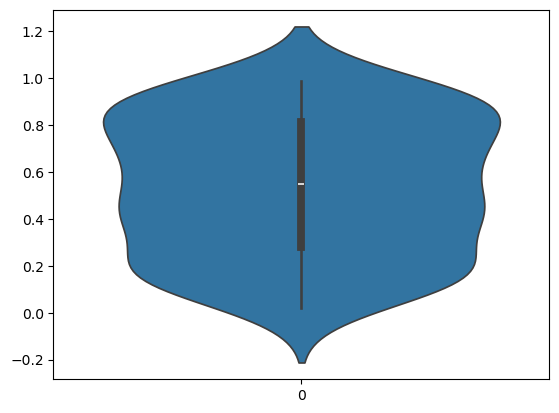

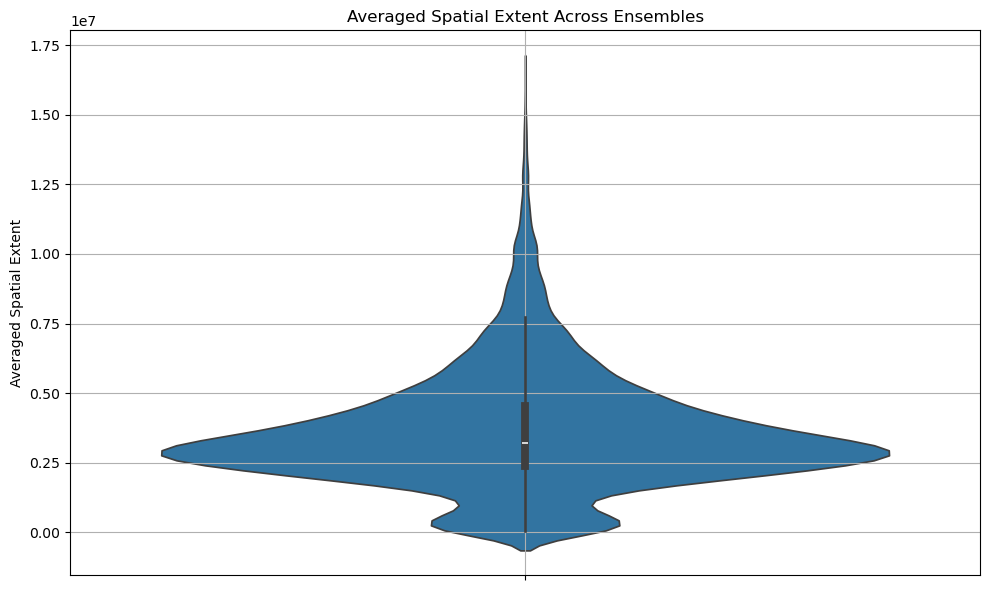

In [31]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

random = np.random.rand(100,1)
sns.violinplot(data=random, inner='box')

with open("spatial_extent.json", "r") as f:
    data = json.load(f)

se_l = []
# Load data
for ensemble in data:
    for object in ensemble:
        se_l.append((sum(object))/len(object))
        

plt.figure(figsize=(10, 6))
sns.violinplot(data=se_l, inner='box')
plt.title("Averaged Spatial Extent Across Ensembles")
plt.ylabel("Averaged Spatial Extent")
plt.grid(True)
plt.tight_layout()
plt.show()

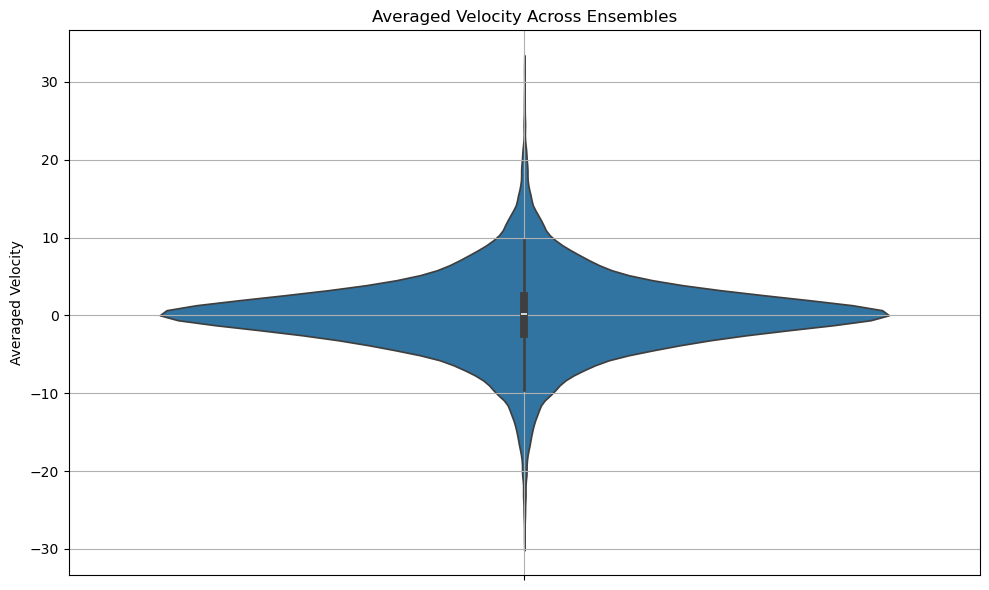

In [27]:
with open("velocities.json", "r") as f:
    data = json.load(f)

se_l = []
# Load data
for ensemble in data:
    for object in ensemble:
        for list in object:
            se_l.append((sum(list))/len(list))
        

plt.figure(figsize=(10, 6))
sns.violinplot(data=se_l, inner='box')
plt.title("Averaged Velocity Across Ensembles")
plt.ylabel("Averaged Velocity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

random = np.random.randint(0, 100, size=10).tolist()
random = random*10**7

# Flatten into long-form DataFrame
df = pd.DataFrame({
    'Value': se_l + random,
    'Group': ['se_l'] * len(se_l) + ['random'] * len(random)
})

sns.violinplot(x='Group', y='Value', data=df, split=True)

plt.title('Random vs Real data')
plt.show()